## 🌱 Cost-Benefit Logic for Agroforestry Adaptation Options

### 🧩 The Problem

When assessing adaptation strategies like adding canopy, changing canopy composition, or switching crops (e.g., from coffee to cacao), we want to compare **costs and benefits** over time under climate risk. But there’s a challenge:

> **CLIMADA’s cost-benefit analysis assumes that exposure values (e.g., yield value) remain the same across scenarios.**

However, when switching to a new crop (e.g., from coffee to cacao), the **baseline value of the exposure itself changes** (e.g., from $1000/ha to $1200/ha). This breaks the assumptions in CLIMADA's default interpolation method.

---

### 🎯 Two Approaches to Estimate Revenue

#### ✅ Approach 1 — Use CLIMADA Directly (works best if exposure value stays constant)
- Use CLIMADA’s AAL (Average Annual Loss) estimates for **present** and **future**
- Interpolate risk reduction over time
- Multiply by baseline exposure value
- Appropriate when *only risk changes*, not baseline value

#### ✅ Approach 2 — Adjust Revenue Over Time (more flexible)
- Start from **baseline yield value (present and future)** in USD/ha
- Use AAL% (present and future) to reduce expected revenue
- Interpolate the **expected revenue per year** across the time horizon

---

### 📊 Input Table for Approach 2

| Measure        | Baseline Yield ($/ha) Present | Baseline Yield ($/ha) Future | AAL (%) Present | AAL (%) Future | Start Year | End Year |
|----------------|-------------------------------|------------------------------|------------------|-----------------|-------------|-----------|
| present        | 1000                          | 1300                         | 0.05             | 0.10            | 2025        | 2040      |
| alternative 1  | 1000                          | 1300                         | 0.03             | 0.08            | 2025        | 2040      |
| alternative 2  | 1200                          | 1500                         | 0.04             | 0.09            | 2025        | 2040      |

---

### 📈 How to Calculate Expected Revenue Per Year

1. **Apply AAL to get expected revenue:**

    \[
    \text{Revenue}_{\text{present}} = \text{Yield}_{\text{present}} \times (1 - \text{AAL}_{\text{present}})
    \]

    \[
    \text{Revenue}_{\text{future}} = \text{Yield}_{\text{future}} \times (1 - \text{AAL}_{\text{future}})
    \]

2. **Interpolate yearly revenue:**

    For each year \( y \in [\text{start}, \text{end}] \):
    
    \[
    \text{Revenue}_y = \text{Revenue}_{\text{present}} + \frac{y - \text{start}}{\text{end} - \text{start}} \cdot (\text{Revenue}_{\text{future}} - \text{Revenue}_{\text{present}})
    \]

3. **Optionally discount to compute NPV**

---

### ✅ Result

- You now have **expected revenues per year**
- You can subtract yearly **costs** to compute **net benefits**
- This allows for comparing adaptation measures, even if exposure value changes


### 📊 Estimating Expected Revenue with Climate Risk

To estimate the expected revenue of different agroforestry or crop configurations under climate risk, follow these steps:

1. **Base Yield Assumption**  
   For each planting system (e.g., coffee with shade, cacao monocrop), assume or estimate the baseline annual yield per hectare in USD.

2. **Average Annual Loss (AAL)**  
   Use CLIMADA to calculate AAL (% of losses due to climate hazard) for both:
   - **Present climate**
   - **Future climate**

3. **Interpolated AAL per year**  
   Linearly interpolate AAL between present and future over your analysis period (e.g., 2025–2040).

4. **Expected Revenue Calculation**  
   For each year:
   \[
   \text{Expected Revenue} = \text{Base Yield} \times (1 - \text{AAL}(t))
   \]

5. **Compare Measures**  
   Repeat the process for each alternative measure (e.g., adding shade trees), adjusting both yield and AAL accordingly. You can then:
   - Plot annual revenues
   - Calculate Net Present Value (NPV)
   - Compare total benefit (e.g., avoided losses or increased income)

This approach allows comparing systems that differ both in productivity and climate resilience.


## 0 - Initial parameters

In [1]:
from pathlib import Path
import os

# Define output and input directories
INPUT_DIR = Path("/Users/viggo/Documents/Programming/Consult/UNU/data")
OUTPUT_DIR = Path("/Users/viggo/Documents/Programming/Consult/UNU/output")

# Define the hazard type
hazard_type = 'Tmax' #'VPD' or 'Tmax' (Temperature)

# Define the crop type
# crop_type = 'Coffea arabica' # 'banana' or 'cacao'

# Define the country
# country = 'MEX'  # 'DOM', 'MEX'

# Define the future scenario ( Use 'plus2C' for 2 degrees Celsius increase for the hazard part)
future_climate_scenario = 'plus2C' # 

# Define the present year and the future year
present_year = 2020
future_year = 2050


## 1 - Canopy compositions

Store canopy and crop compositions for all sites in data frames

In [2]:
import pandas as pd
from tabulate import tabulate

# get the number of sheets in the Excel file apart from the 'Current' sheet
file = INPUT_DIR / "canopy_crop_composition.xlsx"
canopy_comps = pd.ExcelFile(file).sheet_names

# Create a dictionary to hold the canopy composition data
canopy_dict = {}
for sheet in canopy_comps:
    canopy_dict[sheet] = pd.read_excel(file, sheet_name=sheet)

# Sort the canopy composition data by the 'Latitude' and 'Longitude' columns
for sheet, df in canopy_dict.items():
    if 'Latitude' in df.columns and 'Longitude' in df.columns:
        canopy_dict[sheet] = df.sort_values(by=['Latitude', 'Longitude'])

# Modify the DataFrame to match the expected format for Exposures (Perhaps this should done in an early step or manually)
def modify_canopy_crop_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # Rename columns
    df.rename(columns={
        "Latitude": "latitude",
        "Longitude": "longitude"
    }, inplace=True)

    # Generate unique site_id
    df["site_id"] = df.groupby(["latitude", "longitude"]).ngroup()

    return df

# Modify the canopy composition dataframes
for sheet, df in canopy_dict.items():
    canopy_dict[sheet] = modify_canopy_crop_df(df)

# Print the modified DataFrame for the 'present' sheet
print(tabulate(canopy_dict['present'], headers='keys', tablefmt='psql'))


+----+----------+------------------+--------------------+--------------------+-------------+---------------------+------------------------+------------+-------------+-----------------+-----------+
|    | System   |   Plot size (ha) | Species            | Scientific name    |   Plants/ha |   Yield (t/ha/year) |   Per-tree shading (%) |   latitude |   longitude |   Elevation (m) |   site_id |
|----+----------+------------------+--------------------+--------------------+-------------+---------------------+------------------------+------------+-------------+-----------------+-----------|
|  0 | Coffee   |                1 | Coffee (main crop) | Coffea arabica     |         nan |                0.73 |                  nan   |    17.3205 |    -93.1084 |             734 |         0 |
|  1 | Coffee   |                1 | Guama              | Inga spp.          |           1 |              nan    |                   56.7 |    17.3205 |    -93.1084 |             734 |         0 |
|  2 | Coffee  

Check that the site ids are consistent across all options

In [3]:
# Check that all that all the dataframes have the same site_ids matched to  latitude and longitude
# Use the first sheet's mapping as the reference
reference_sheet = list(canopy_dict.keys())[0]
reference_df = canopy_dict[reference_sheet]
reference_mapping = reference_df[["latitude", "longitude", "site_id"]].drop_duplicates().sort_values(by=["latitude", "longitude"]).reset_index(drop=True)

# Compare with each other sheet
for sheet, df in canopy_dict.items():
    if sheet == reference_sheet:
        continue
    current_mapping = df[["latitude", "longitude", "site_id"]].drop_duplicates().sort_values(by=["latitude", "longitude"]).reset_index(drop=True)
    
    if not reference_mapping.equals(current_mapping):
        print(f"⚠️ Inconsistent site_id mapping in sheet: {sheet}")
    else:
        print(f"✅ Consistent site_id mapping in sheet: {sheet}")

✅ Consistent site_id mapping in sheet: alternative 1
✅ Consistent site_id mapping in sheet: alternative 2
✅ Consistent site_id mapping in sheet: alternative 3


## 2 - Exposure

Make the exposure by calculating 

- the tree shade for each site
- The value unit (production) for each site 

In [4]:
from climada.entity import Exposures


def make_exposure_of_canopy_crop_df(df: pd.DataFrame,
                                     ref_year: int = 2020, 
                                     price_per_ton_dict=None,
                                     value_unit: str = None,
                                     max_trees_per_ha: int = 144) -> Exposures:
    df = df.copy()

    # 1. Calculate Production (t)
    df["Production (t)"] = df["Plot size (ha)"] * df["Yield (t/ha/year)"]

    # 2. Handle pricing logic
    if price_per_ton_dict:
        if not value_unit:
            raise ValueError("If 'price_per_ton_dict' is provided, 'value_unit' must be explicitly defined.")
        price_col = f"price ({value_unit}/t)"
        df[price_col] = df["Scientific name"].map(price_per_ton_dict)
        df["value"] = df.apply(
            lambda row: row["Production (t)"] * row[price_col] if pd.notna(row[price_col]) else row["Production (t)"],
            axis=1
        )
    else:
        value_unit = value_unit or "Tonnes"
        price_col = None
        df["value"] = df["Production (t)"]

    # 3. Calculate tree shade per site
    df['Per-tree shading (%)'] /= max_trees_per_ha
    df['Shade contribution (%)'] = df['Per-tree shading (%)'] * df['Plants/ha'] * df['Plot size (ha)']
    df['Tree Shade (%)'] = df.groupby("site_id")['Shade contribution (%)'].transform("sum")
    df['canopy_cover'] = df['Tree Shade (%)']

    # 4. Filter rows with missing value and crop type
    df = df[df['value'].notna()]
    

    # 5. Create Exposures object
    exp = Exposures(df)
    exp.ref_year = ref_year
    exp.value_unit = value_unit
    exp.check()

    return exp


# Define the price per ton for each crop
price_per_ton_dict = {
    "Coffea arabica": 3200,  # USD per ton for coffee
    "Cacao": 2500,           # USD per ton for cacao
    "Banana": 1000           # USD per ton for banana
}
value_unit = 'USD'  # Define the value unit for the exposures

# Create Exposures for each canopy composition 
exposures_dict = {}
for sheet, df in canopy_dict.items():
    exposures_dict[sheet] = make_exposure_of_canopy_crop_df(
        df,
        price_per_ton_dict=price_per_ton_dict,
        value_unit='USD',
        max_trees_per_ha=144  # Assuming a maximum of 144 trees per hectare
    )
# Print the Exposures for the 'present' sheet
print(tabulate(exposures_dict['present'].gdf, headers='keys', tablefmt='psql'))


2025-08-01 15:26:06,089 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
2025-08-01 15:26:06,092 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
2025-08-01 15:26:06,094 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
2025-08-01 15:26:06,097 - climada.entity.exposures.base - WARNING - There are no impact functions assigned to the exposures
+----+----------+------------------+--------------------+-------------------+-------------+---------------------+------------------------+-----------------+-----------+------------------+-----------------+---------+--------------------------+------------------+----------------+----------------------------------------------+
|    | System   |   Plot size (ha) | Species            | Scientific name   |   Plants/ha |   Yield (t/ha/year) |   Per-tree shading (%) |   Elevation (m) |   site_id |   Product

Display the added trees per site 

In [5]:
# import pandas as pd

# def build_canopy_per_meas_df(exposures_dict):
#     """
#     Generate a DataFrame with columns:
#         Measure | site_id | canopy_cover

#     Args:
#         exposures_dict (dict): Dictionary of Exposures objects keyed by measure name.

#     Returns:
#         pd.DataFrame
#     """
#     records = []

#     for measure_name, exp in exposures_dict.items():
#         gdf = exp.gdf[["site_id", "canopy_cover"]].copy()
#         gdf["Measure"] = measure_name
#         records.append(gdf)

#     canopy_df = pd.concat(records, ignore_index=True)

#     # Reorder columns
#     canopy_df = canopy_df[["Measure", "site_id", "canopy_cover"]]

#     # Optional: round for readability
#     canopy_df["canopy_cover"] = canopy_df["canopy_cover"].round(2)

#     return canopy_df

# canopy_per_meas_df = build_canopy_per_meas_df(exposures_dict)
# display(canopy_per_meas_df)


Display the added canopy

In [6]:
def generate_added_canopy_dict_abs(baseline_df, alternative_df) -> dict:
    """
    Compare two canopy compositions and return the absolute number of trees added
    per site and species.

    Args:
        baseline_df (pd.DataFrame): Baseline canopy composition.
        alternative_df (pd.DataFrame): Alternative canopy composition.

    Returns:
        dict: {site_id: {species_name: added_tree_count, ...}, ...}
    """
    # Ensure consistent site_id type
    baseline_df["site_id"] = baseline_df["site_id"].astype(str)
    alternative_df["site_id"] = alternative_df["site_id"].astype(str)

    # Compute absolute trees = Plants/ha × Plot size (ha)
    baseline_df["abs_trees"] = baseline_df["Plants/ha"] * baseline_df["Plot size (ha)"]
    alternative_df["abs_trees"] = alternative_df["Plants/ha"] * alternative_df["Plot size (ha)"]

    base_grouped = baseline_df.groupby(["site_id", "Species"])["abs_trees"].sum()
    alt_grouped = alternative_df.groupby(["site_id", "Species"])["abs_trees"].sum()

    all_keys = set(base_grouped.index).union(set(alt_grouped.index))

    added_canopy = {}

    for site_id, species in all_keys:
        base_val = base_grouped.get((site_id, species), 0)
        alt_val = alt_grouped.get((site_id, species), 0)
        added = max(alt_val - base_val, 0)

        if site_id not in added_canopy:
            added_canopy[site_id] = {}

        added_canopy[site_id][species] = int(round(added))

    return added_canopy

In [7]:
import pandas as pd

# Generate the wide-format added trees DataFrame
baseline_df = canopy_dict["present"]
all_added_rows = []

for meas_name, alternative_df in canopy_dict.items():
    added_canopy = generate_added_canopy_dict_abs(baseline_df, alternative_df)
    
    for site_id, species_dict in added_canopy.items():
        for species, count in species_dict.items():
            all_added_rows.append({
                "Measure": meas_name,
                "site_id": site_id,
                species: count  # will pivot this later
            })

# Convert to DataFrame
long_df = pd.DataFrame(all_added_rows)

# Melt species columns to long format to aggregate correctly
long_df = long_df.melt(id_vars=["Measure", "site_id"], var_name="tree_species", value_name="added")

# Pivot to wide format
add_trees_df = long_df.pivot_table(
    index=["Measure", "site_id"],
    columns="tree_species",
    values="added",
    fill_value=0
).reset_index()

# Sort columns so 'Measure' and 'site_id' come first
cols = ['Measure', 'site_id'] + sorted(c for c in add_trees_df.columns if c not in ['Measure', 'site_id'])
add_trees_df = add_trees_df[cols]

# Save to Excel
output_file = OUTPUT_DIR / "added_trees.xlsx"
add_trees_df.to_excel(output_file, index=False)

print(add_trees_df)


tree_species        Measure site_id  Avocado  Bitter orange  Breadfruit  \
0             alternative 1       0      0.0            3.0         0.0   
1             alternative 1       1      0.0            0.0         0.0   
2             alternative 2       0      0.0           13.0         0.0   
3             alternative 2       1      0.0            0.0         0.0   
4             alternative 3       0      0.0            3.0         5.0   
5             alternative 3       1      0.0            0.0         0.0   
6                   present       0      0.0            0.0         0.0   
7                   present       1      0.0            0.0         0.0   

tree_species  Coffee (main crop)  Guama  Sapote  Sweet orange  
0                            0.0   19.0     5.0          21.0  
1                            0.0   39.0     0.0           0.0  
2                            0.0    0.0     5.0           7.0  
3                            0.0    9.0     0.0           0.0  
4   

In [8]:
# # Ensure both DataFrames use the same types for 'site_id'
# canopy_per_meas_df["site_id"] = canopy_per_meas_df["site_id"].astype(str)
# add_trees_df_renamed = add_trees_df.rename(columns={"meas_name": "Measure"})
# add_trees_df_renamed["site_id"] = add_trees_df_renamed["site_id"].astype(str)

# # Merge
# merged_df = pd.merge(
#     canopy_per_meas_df,
#     add_trees_df_renamed,
#     on=["Measure", "site_id"],
#     how="left"
# )

# # Optional: sort or fill missing values
# add_trees_canopy_df = merged_df.sort_values(by=["Measure", "site_id"]).reset_index(drop=True)

# # Display
# display(add_trees_canopy_df)

# # Save the DataFrame to an Excel file
# output_file = OUTPUT_DIR / "added_trees.xlsx"
# add_trees_canopy_df.to_excel(output_file, index=False)

## 3 – Hazard 


- Here we do it a little bit differetn then the common CLIMADA as each grid point has a uniquiew adaption measure given by the canopy level.
- We will need to store a current and a future hazard set which will be usefulle for the risk comaprisson over time and the CB analysis.
- We download both historical weather and future weather (which can be changed based on RCP levels)

Download the data 

https://www.climatologylab.org/terraclimate.html

🌡️ VPD – Vapour Pressure Deficit

We model Vapour Pressure Deficit (VPD) as a key climate hazard, similar to the paper Kath et al. (2022), Nature Food. The study provides a vulnerability curve linking mean VPD during the growing season to yield impacts for coffee.

We calculate the mean VPD over the crop-specific growing season: Mexico: June to December

📂 Loading 37 files for variable 'tmax'...
📆 Filtering to months: [5, 6, 7, 8, 9, 10, 11]
🧮 Aggregating by year using 'mean'...
📌 Reshaping data to [year, lat*lon] array...
🔄 Replacing NaNs with 0.0...
🧱 Converting to sparse matrix...
🗺️ Extracting lat/lon centroids...
📦 Creating Hazard object...
📂 Loading 30 files for variable 'tmax'...
📆 Filtering to months: [5, 6, 7, 8, 9, 10, 11]
🧮 Aggregating by year using 'mean'...
📌 Reshaping data to [year, lat*lon] array...
🔄 Replacing NaNs with 0.0...
🧱 Converting to sparse matrix...
🗺️ Extracting lat/lon centroids...
📦 Creating Hazard object...


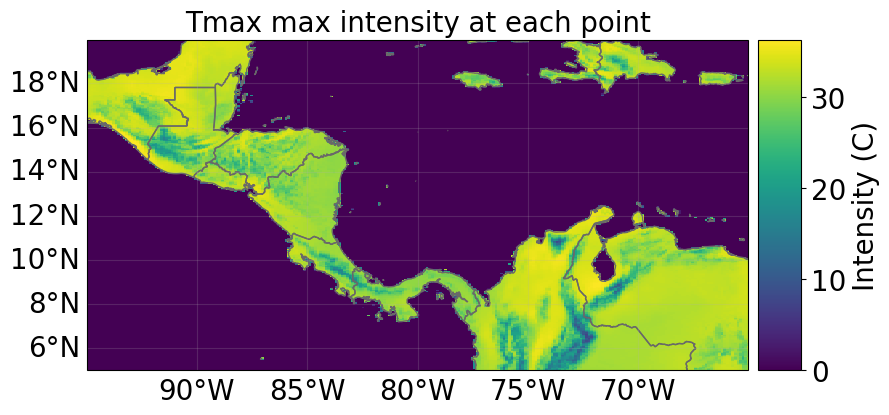

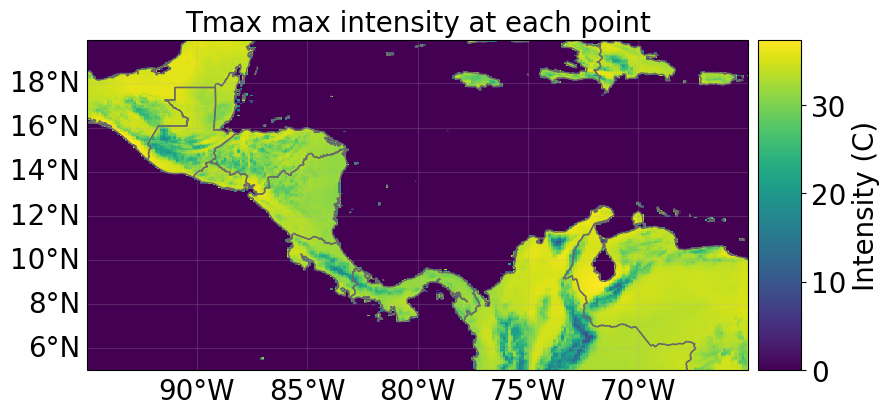

In [9]:
from utils_cb import create_hazard_from_nc_files
from climada.hazard import Hazard

# Determine the corresponding parameters for the hazard type
nc_files = {'present': [], 'future': []}
haz_dict = {'present': Hazard, 'future': Hazard}

if hazard_type == 'VPD':
    agg = 'mean'
    varname = 'vpd'
    nc_files['present'] = sorted(INPUT_DIR.glob("terra_climate/TerraClimate_vpd_*_CA.nc"))
    nc_files['future'] = sorted(INPUT_DIR.glob(f"terra_climate/TerraClimate_{future_climate_scenario}_vpd_*_CA.nc"))
    units = 'kPa'
    months = [5, 6, 7, 8, 9, 10, 11]  # April to November
elif hazard_type == 'Tmax':
    agg = 'mean'
    varname = 'tmax'
    nc_files['present'] = sorted(INPUT_DIR.glob("terra_climate/TerraClimate_tmax_*_CA.nc"))
    nc_files['future'] = sorted(INPUT_DIR.glob(f"terra_climate/TerraClimate_{future_climate_scenario}_tmax_*_CA.nc"))
    units = 'C'
    months = [5, 6, 7, 8, 9, 10, 11] # April to November


# Store the hazard type and parameters in a dictionary
for key in nc_files:
    haz_dict[key] = create_hazard_from_nc_files(
                        nc_files[key],
                        varname=varname,
                        haz_type=hazard_type,
                        units=units,
                        agg=agg,
                        months=months,
                        nan_replacement=0.0  # Use NaN to keep sparse matrix
                    )
    # Plot the hazard object
    haz_dict[key].plot_intensity(0)


### 3.2 – Hazard intensity per site

Explain clearly why we do this approach and not the imapct function set

- Since each site may have a different tree shaidng this could constitute to the measure being that has their own impact fcuntion id the opld climada cost-benfit is a bit slow of doing this ... 

Since the adaption measure is the change the canopy level at each site in relation to the curret levels. Each site may already be exposed to a different hazard set


This Reproject the hazard values on the exposure sites and derive a different hazard set given the canopy level.. We do this because the hazard intenity will later on depend on the canopy level at each given site and some sites corresponds to the smae centroid in the hazard file.



Reproject the raw hazard values on the exposure sites. 

🔁 Interpolating hazard values to exposure coordinates...
Site-level hazard for present:
⚠️ No intensity data available for present. The hazard may not have multiple columns.
🔁 Interpolating hazard values to exposure coordinates...
Site-level hazard for future:
⚠️ No intensity data available for future. The hazard may not have multiple columns.


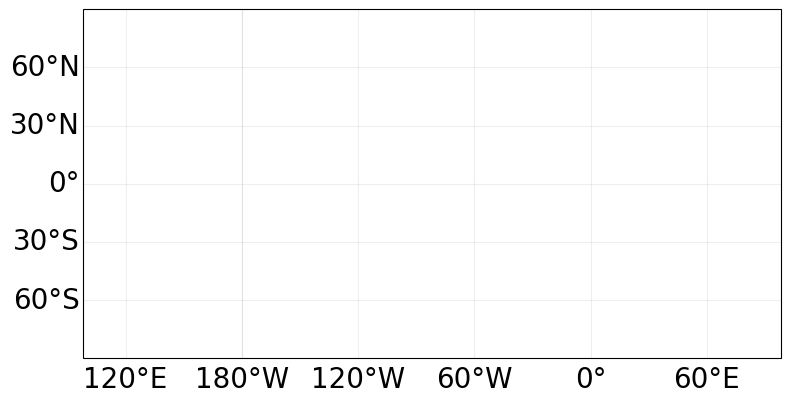

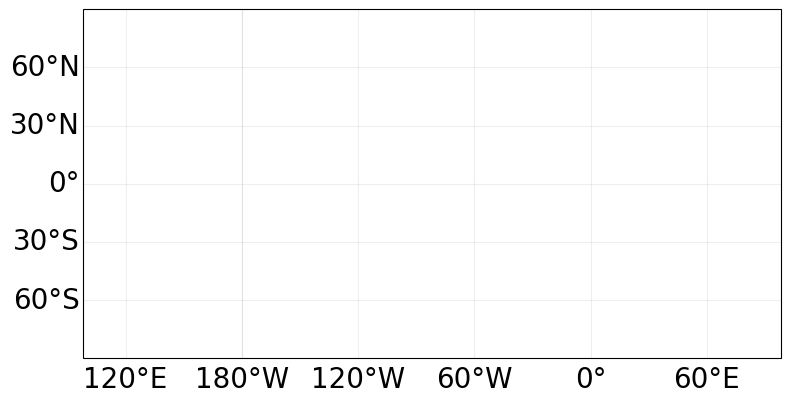

In [10]:
from utils_cb import reproject_hazard_to_exposures

haz_site_dict = {'present': Hazard, 'future': Hazard}

# Reproject the hazard to the exposure sites use the site coordintaes fomr the refrecne site present
for time in haz_dict:
    # Reproject the hazard to the exposure sites
    haz_site_dict[time] = reproject_hazard_to_exposures(hazard= haz_dict[time],
                                                       exp = exposures_dict['present'])
                                                       
    # Plot the site-level hazard if the number of columns is greater than 1
    try:
        print(f"Site-level hazard for {time}:")
        haz_site_dict[time].plot_intensity(0)
    except:
        print(f"⚠️ No intensity data available for {time}. The hazard may not have multiple columns.")
        continue


We now make use of the `adjust_hazard_with_exposure_modifier` Define function in tersm of how much the canopy level changes the hazard.

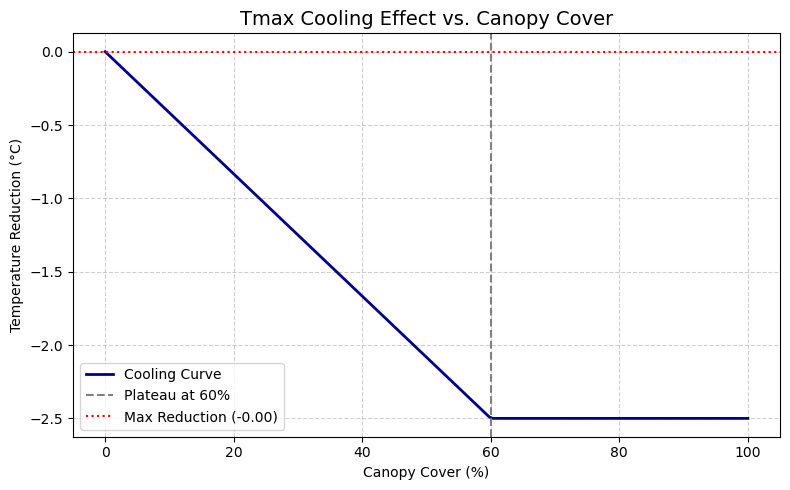

In [26]:
from utils_cb import helper_adj_fcn_canopy_tmax, helper_adj_fcn_canopy_vpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Decide the adjustment function and its parameters
if hazard_type.upper() == 'TMAX':
    adjustment_fn = helper_adj_fcn_canopy_tmax
    adjustment_kwargs = {
        "max_cooling": 2.5,
        "plateau_at": 60
    }
    ylabel = "Temperature Reduction (°C)"
    title = "Tmax Cooling Effect vs. Canopy Cover"
    label = "Cooling Curve"
elif hazard_type.upper() == 'VPD':
    adjustment_fn = helper_adj_fcn_canopy_vpd
    adjustment_kwargs = {
        "max_cooling": 3.0,
        "plateau_at": 50,
        "vpd_sensitivity": 0.15
    }
    ylabel = "VPD Reduction (kPa)"
    title = "VPD Reduction vs. Canopy Cover"
    label = "VPD Reduction Curve"
else:
    raise ValueError(f"Unsupported hazard type: {hazard_type}")


# Inputs
canopy = np.linspace(0, 100, 200)
n_sites = len(canopy)

# Apply adjustment function
reduction = adjustment_fn(
    hazard_matrix=np.zeros((1, n_sites)),  # Dummy input,
    exposure_gdf=pd.DataFrame({'canopy_cover': canopy}),
    **adjustment_kwargs
)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(canopy, reduction, label=label, linewidth=2, color="darkblue")
plt.axvline(adjustment_kwargs["plateau_at"], color='gray', linestyle='--', label=f'Plateau at {adjustment_kwargs["plateau_at"]}%')
plt.axhline(reduction.max(), color='red', linestyle=':', label=f'Max Reduction ({reduction.max():.2f})')

plt.title(title, fontsize=14)
plt.xlabel("Canopy Cover (%)")
plt.ylabel(ylabel)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


This function will be used to change the hazard intensity given the canopy level. We will use it to set the baseline 

In [27]:
from utils_cb import apply_canopy_scenario, adjust_hazard_with_exposure_modifier

def adjust_hazard(exposure,
                  hazard,
                  adjustment_fn,
                  adjustment_kwargs,
                  set_all_canopy_scenario=None):
    """ Adjusts the hazard based on the exposure and canopy scenario.
    Args:
        exposure (Exposures): The exposure object containing canopy cover data.
        hazard (Hazard): The hazard object to be adjusted.
        canopy_scenario (str): The canopy scenario to apply.
        adjustment_fn (function): The function to adjust the hazard.
        adjustment_kwargs (dict): Additional arguments for the adjustment function.
    Returns:
        Hazard: The adjusted hazard object.
    """
    # Apply the canopy scenario to the exposure
    if set_all_canopy_scenario is not None:
        canopy_scenario = set_all_canopy_scenario
    else:
        canopy_scenario = "current"  # Default scenario if not provided
    # Adjust the exposure using the canopy scenario
    adjusted_exposure = apply_canopy_scenario(exp=exposure, canopy_scenario=canopy_scenario)

    # Adjust the hazard using the adjustment function
    adjusted_hazard = adjust_hazard_with_exposure_modifier(
        exposure=adjusted_exposure,
        hazard=hazard,
        adjustment_fn=adjustment_fn,
        adjustment_kwargs=adjustment_kwargs
    )
    return adjusted_hazard

Check if the adjusment function works

In [28]:
# Apply the adjustment function to the hazard object
haz_orig = haz_site_dict['future']  # Use the present hazard for adjustment
haz_site_adjusted_example = adjust_hazard(
    exposure = exposures_dict['present'],  # Use the present exposures
    hazard = haz_orig, # Use the present hazard for adjustment
    adjustment_fn = adjustment_fn,
    adjustment_kwargs=adjustment_kwargs,
    set_all_canopy_scenario=None  # Use the current canopy scenario or use a specific canopy cover value, e.g. 50
)


import numpy as np

def print_sparse_matrix_diff(haz_original, haz_adjusted, tolerance=1e-6):
    """Prints the non-zero differences between two sparse hazard matrices."""
    orig = haz_original.intensity.tocoo()
    adj = haz_adjusted.intensity.tocoo()

    # Convert to dictionaries for fast access
    orig_dict = {(i, j): v for i, j, v in zip(orig.row, orig.col, orig.data)}
    adj_dict = {(i, j): v for i, j, v in zip(adj.row, adj.col, adj.data)}

    all_keys = set(orig_dict.keys()).union(set(adj_dict.keys()))
    diffs = []

    for key in sorted(all_keys):
        orig_val = orig_dict.get(key, 0.0)
        adj_val = adj_dict.get(key, 0.0)
        delta = adj_val - orig_val
        if abs(delta) > tolerance:
            diffs.append((key[0], key[1], orig_val, adj_val, delta))

    if not diffs:
        print("✅ No significant differences found (within tolerance).")
    else:
        print(f"🔍 {len(diffs)} cells with differences:")
        for i, j, orig_val, adj_val, delta in diffs:
            print(f"  ({i}, {j}): original={orig_val:.4f}, adjusted={adj_val:.4f}, diff={delta:+.4f}")

                  
print_sparse_matrix_diff(haz_orig, haz_site_adjusted_example)

🔍 60 cells with differences:
  (0, 0): original=30.9571, adjusted=29.0358, diff=-1.9213
  (0, 1): original=25.7000, adjusted=24.0165, diff=-1.6835
  (1, 0): original=30.9286, adjusted=29.0073, diff=-1.9213
  (1, 1): original=25.4143, adjusted=23.7308, diff=-1.6835
  (2, 0): original=30.9429, adjusted=29.0216, diff=-1.9213
  (2, 1): original=25.8857, adjusted=24.2022, diff=-1.6835
  (3, 0): original=30.5714, adjusted=28.6501, diff=-1.9213
  (3, 1): original=26.1714, adjusted=24.4879, diff=-1.6835
  (4, 0): original=30.5429, adjusted=28.6216, diff=-1.9213
  (4, 1): original=26.0714, adjusted=24.3879, diff=-1.6835
  (5, 0): original=30.5286, adjusted=28.6073, diff=-1.9213
  (5, 1): original=26.4571, adjusted=24.7736, diff=-1.6835
  (6, 0): original=30.4714, adjusted=28.5501, diff=-1.9213
  (6, 1): original=26.2000, adjusted=24.5165, diff=-1.6835
  (7, 0): original=30.0857, adjusted=28.1644, diff=-1.9213
  (7, 1): original=26.1143, adjusted=24.4308, diff=-1.6835
  (8, 0): original=30.3571,

### 3.3 Store the baseline hazard

Site-level hazard for present:
Not enough data to plot the hazard for present. The hazard may not sufficient amount of centroids.
Site-level hazard for future:
Not enough data to plot the hazard for future. The hazard may not sufficient amount of centroids.


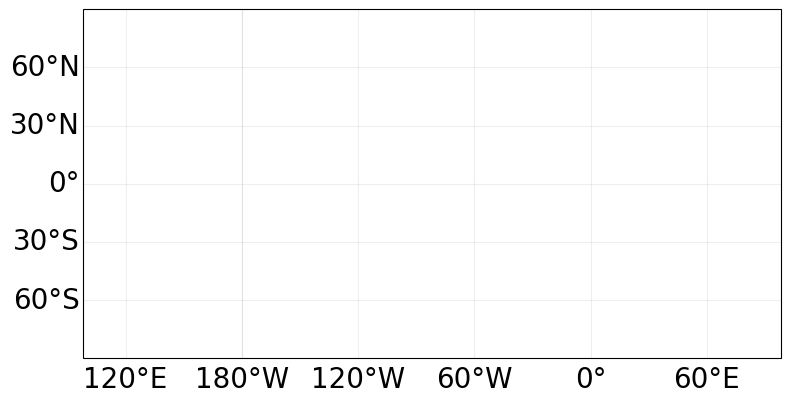

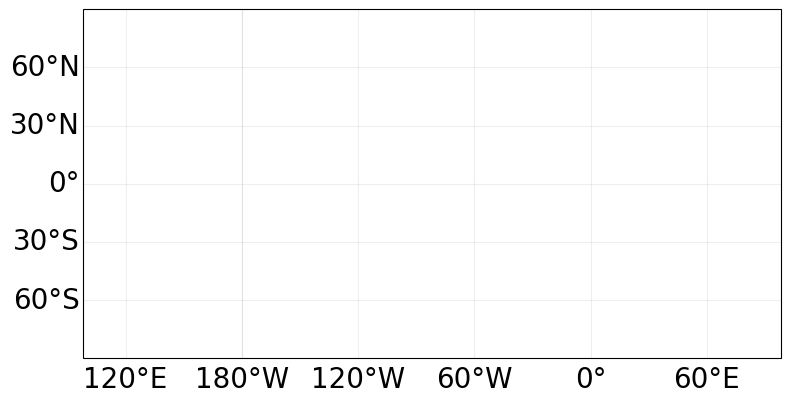

In [29]:
haz_baseline_dict = {}

for time in ['present', 'future']:
    # Apply the adjustment function to the hazard object
    haz_baseline_dict[time] = adjust_hazard(
        exposure = exposures_dict['present'],  # Use the present exposures
        hazard = haz_site_dict[time], # Use the present hazard for adjustment
        adjustment_fn = adjustment_fn,
        adjustment_kwargs=adjustment_kwargs,
        set_all_canopy_scenario=None  # Use the current canopy scenario or use a specific canopy cover value, e.g. 50
    )

    # Plot the site-level hazard if the number of columns is greater than 1
    try:
        print(f"Site-level hazard for {time}:")
        haz_baseline_dict[time].plot_intensity(0)
    except:
        print(f"Not enough data to plot the hazard for {time}. The hazard may not sufficient amount of centroids.")
        continue

## 4 – Impact function (Vulnerability)

As mentioned in Step 3, the vulnerability curve is sourced from the following study: [Kath et al. (2022), *Nature Food*](https://www.nature.com/articles/s43016-022-00614-8)


Index: 0, Value: 0.18126924692201807
Intensity: [0.18126925 0.09516258 0.         0.25918178 0.5034147 ]
Index: 1, Value: 0.09516258196404037
Intensity: [0.         0.09516258 0.         0.25918178 0.5034147 ]
Index: 2, Value: 0.0
Intensity: [0.         0.         0.         0.25918178 0.5034147 ]


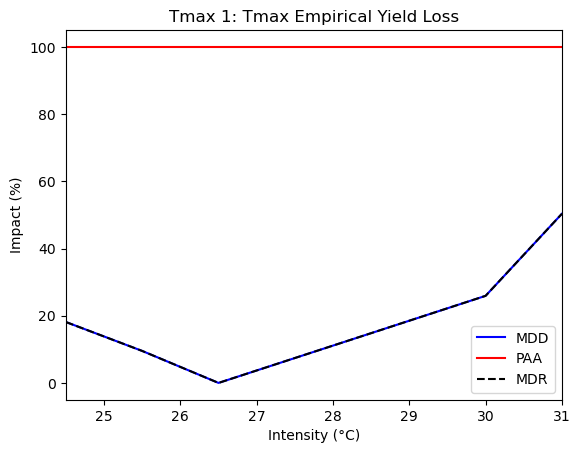

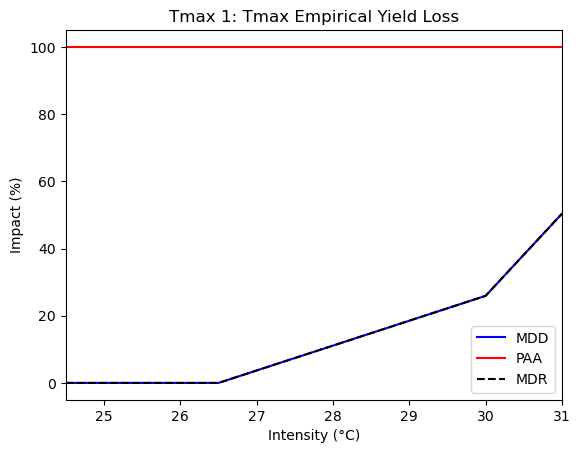

In [30]:
from utils_cb import impact_func_from_kath

import pandas as pd
import numpy as np
from climada.entity import ImpactFunc, ImpactFuncSet


# Create an ImpactFuncSet with the VPD impact function
imp_fun_set = ImpactFuncSet()


# Coffe has id # 1, Banana has id 2, Cacao has id 3
if hazard_type.upper() == 'TMAX':
    impf = impact_func_from_kath(
        file_path= "tasmax_effect_approximation.csv",
        intensity_col="Mean_Tasmax_C",
        yield_col="Effect_Central",
        only_yield_losses=True,
        haz_type="Tmax",
        unit="°C",
        if_id= 1,
        name="Tmax Empirical Yield Loss"
    )
elif hazard_type.upper() == 'VPD':
    impf = impact_func_from_kath(
        file_path= "vpd_effect_approximation.csv",
        intensity_col="Mean_VPD_kPa",
        yield_col="Effect_Central",
        only_yield_losses=True,
        haz_type="VPD",
        unit="kPa",
        if_id= 1,
        name="VPD Empirical Yield Loss"
    )

impf.plot()

# Adjust the impact function intensity to be zero before the increa
for idx, value in enumerate(impf.mdd):
    print(f"Index: {idx}, Value: {value}")
    print(f"Intensity: {impf.mdd}")
    if value > 0:
        impf.mdd[idx] = 0.0
    else:
        break

impf.plot()

# Add the impact function to the ImpactFuncSet
imp_fun_set.append(impf)


Store the impact function for the present and future

In [31]:
# Store the impact function in impact function set
import copy

imp_fun_set_dict = {'present': copy.deepcopy(imp_fun_set),  # Impact function set for the present climate scenario
                     'future': copy.deepcopy(imp_fun_set)  # Impact function set for the future climate scenario
                     }

Add the impact function id to the exposure objects

In [32]:
# Set the impact function for the hazard type
for key, exp in exposures_dict.items():
    # Coffe has id # 1, Banana has id 2, Cacao has id 3
    exp.gdf[f"impf_{hazard_type}"] = np.where(
        exp.gdf["Scientific name"].str.lower() == "coffea arabica", 1, 0
    )


## 5 - Discount rates 

Make a dsicount rate to use

<Axes: title={'center': 'Discount rates'}, xlabel='Year', ylabel='discount rate (%)'>

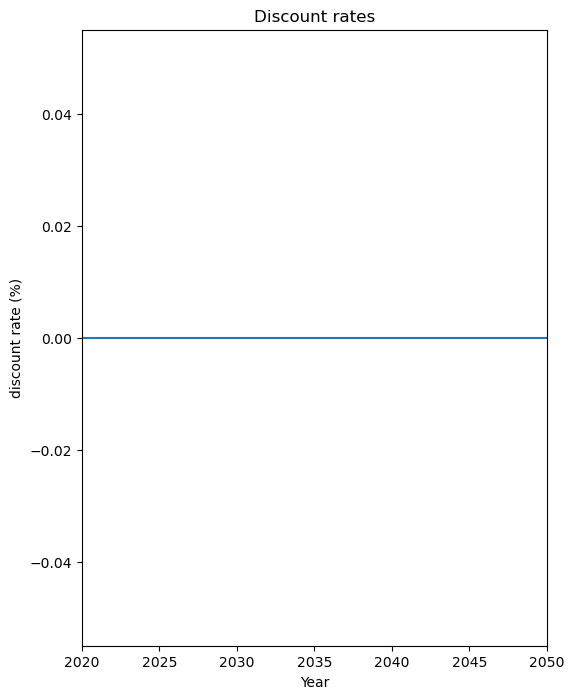

In [33]:
from climada.entity import DiscRates


year_range = np.arange( present_year, future_year + 1)
n_years = len(year_range)
annual_discount_zero = np.zeros(n_years)
annual_discount_stern = np.ones(n_years) * 0.014

discount_zero = DiscRates(year_range, annual_discount_zero)
discount_stern = DiscRates(year_range, annual_discount_stern)

# Create the entity for the present climate scenario
disc_rate = discount_stern  # Use the zero discount rate for the present scenario
disc_rate = discount_zero  # Use the zero discount rate for the present scenario

disc_rate.plot()

## 6 – Adaptation Measures 

### 6.1 - Costs and Income calculations

In [34]:
# Import the canopy price data
file = INPUT_DIR / "Crop Price Data.xlsx"
costs_df = pd.read_excel(file, sheet_name="Costs")
revenues_df = pd.read_excel(file, sheet_name="Revenue")

print(f"Costs DataFrame:\n{tabulate(costs_df, headers='keys', tablefmt='grid')}\n")
print(f"Revenues DataFrame:\n{tabulate(revenues_df, headers='keys', tablefmt='grid')}\n")


print(f"Canopy composition for the present scenario:\n{tabulate(canopy_dict['present'], headers='keys', tablefmt='grid')}\n")
print(f"Canopy composition for alternative 1:\n{tabulate(canopy_dict['alternative 1'], headers='keys', tablefmt='grid')}\n")

Costs DataFrame:
+----+------------------------------------+----------------------+-----------------------+--------------------------+--------------------+--------+
|    | Species                            |   Nursery cost (RD$) |   Planting cost (RD$) |   Maintenance cost (RD$) |   Total Cost (RD$) |   Year |
+====+====================================+======================+=======================+==========================+====================+========+
|  0 | Guama (Inga spp.)                  |                   50 |                    25 |                       20 |                 95 |      1 |
+----+------------------------------------+----------------------+-----------------------+--------------------------+--------------------+--------+
|  1 | Cuban Pine Nut (Gliricidia sepium) |                   30 |                    35 |                       20 |                 85 |      1 |
+----+------------------------------------+----------------------+-----------------------+-----

In [35]:
import pandas as pd

# Mapping from canopy crop names to grouped names in cost/revenue tables
canopy_to_cost_species = {
    "Guama": "Guama (Inga spp.)",
    "Breadfruit": "Cuban Pine Nut (Gliricidia sepium)",
    "Bitter orange": "Citrus fruits",
    "Sweet orange": "Citrus fruits",
    "Avocado": "Avocado",
    "Sapote": "Sapodilla",
    "Chestnut": "Chestnut"
}

def compute_total_cashflows_and_npv(costs_df, revenue_df, added_canopy,
                                    start_year, end_year, fx_rate, disc_rate):
    """
    Compute total cashflows and NPVs across all sites.

    Returns:
        - net_npv (float): Net Present Value (USD)
        - cost_npv (float): Cost NPV (USD)
        - rev_npv (float): Revenue NPV (USD)
        - cashflows_df (pd.DataFrame): Aggregated time series across all sites
    """
    annual_data = {year: {"Costs": 0, "Revenue": 0} for year in range(start_year, end_year + 1)}

    for site_data in added_canopy.values():
        species_counts = {}
        for canopy_name, count in site_data.items():
            grouped = canopy_to_cost_species.get(canopy_name)
            if not grouped:
                print(f"⚠️ No mapping for '{canopy_name}' — skipping.")
                continue
            species_counts[grouped] = species_counts.get(grouped, 0) + count

        cost_subset = costs_df[costs_df["Species"].isin(species_counts)]
        revenue_subset = revenue_df[revenue_df["Species"].isin(species_counts)]

        for year in range(start_year, end_year + 1):
            rel_year = year - start_year + 1

            for species, count in species_counts.items():
                # --- Cost ---
                cost_row = cost_subset.query("Species == @species and Year == @rel_year")
                if cost_row.empty:
                    cost_row = cost_subset.query("Species == @species and Year <= @rel_year").sort_values("Year")
                cost = cost_row["Total Cost (RD$)"].iloc[-1] if not cost_row.empty else 0
                annual_data[year]["Costs"] += count * cost

                # --- Revenue ---
                rev_row = revenue_subset[revenue_subset["Species"] == species]
                if not rev_row.empty:
                    fruit_year = start_year + rev_row["Time Until Fruits"].values[0] - 1
                    if year >= fruit_year:
                        revenue = rev_row["Total production per plant (RD$/plant)"].values[0]
                        annual_data[year]["Revenue"] += count * revenue

    # Final DataFrame
    df = pd.DataFrame([
        {"Year": year,
         "Costs": -data["Costs"] / fx_rate,
         "Revenue": data["Revenue"] / fx_rate}
        for year, data in annual_data.items()
    ])
    df["Netto"] = df["Revenue"] + df["Costs"]

    # NPV calculations
    net_npv = disc_rate.net_present_value(df["Year"].min(), df["Year"].max(), df["Netto"].values)
    cost_npv = disc_rate.net_present_value(df["Year"].min(), df["Year"].max(), df["Costs"].values)
    rev_npv = disc_rate.net_present_value(df["Year"].min(), df["Year"].max(), df["Revenue"].values)

    return net_npv, cost_npv, rev_npv, df

net_npv, cost_npv, rev_npv, cashflows_df = compute_total_cashflows_and_npv(
    costs_df, revenues_df, added_canopy,
    start_year=2020, end_year=2040,
    fx_rate=60, disc_rate=disc_rate
)

print(f"💰 Total Net NPV: ${net_npv:,.2f}")
print(f"📉 Total Cost NPV: ${cost_npv:,.2f}")
print(f"📈 Total Revenue NPV: ${rev_npv:,.2f}")
display(cashflows_df)



⚠️ No mapping for 'Coffee (main crop)' — skipping.
⚠️ No mapping for 'Coffee (main crop)' — skipping.
💰 Total Net NPV: $1,241.25
📉 Total Cost NPV: $-198.75
📈 Total Revenue NPV: $1,440.00


,Year,Costs,Revenue,Netto
0,2020,-15.583333,0.0,-15.583333
1,2021,-5.500000,0.0,-5.500000
2,2022,-8.166667,0.0,-8.166667
3,2023,-9.416667,80.0,70.583333
4,2024,-9.416667,80.0,70.583333
5,2025,-9.416667,80.0,70.583333
6,2026,-9.416667,80.0,70.583333
7,2027,-9.416667,80.0,70.583333
8,2028,-9.416667,80.0,70.583333
9,2029,-9.416667,80.0,70.583333


### 6.2 - Define the adaption measures

In [37]:
from climada.entity.measures import Measure, MeasureSet

# Create a meaure set to store the measures
meas_set_dict = {'present': MeasureSet(),  # Measure set for the present climate scenario
                'future': MeasureSet()  # Measure set for the future climate scenario
                }

# Get the measure names from the canopy composition dictionary
measure_names = [meas_name for meas_name in canopy_dict.keys() if meas_name != 'present'] 
print(f"Measure names: {measure_names}")

# Create measures for each canopy composition
for time in ['present', 'future']:
    # Create a measure for each canopy composition
    for measure_name in measure_names:
 
        ## Hazard adjustment
        # Compute the hazard using the exposure object and canopy level
        haz_meas = adjust_hazard(
                exposure = exposures_dict[measure_name], # If the canopy level changes the yield, we need to adjust the exposure we need to adjust the exposure
                hazard = haz_site_dict[time],
                adjustment_fn = adjustment_fn,
                adjustment_kwargs=adjustment_kwargs,
                set_all_canopy_scenario=None  # Use the current canopy scenario or use a specific canopy cover value, e.g. 50
            )
        # Save the hazard to the output directory
        haz_file = OUTPUT_DIR / f"haz_{measure_name}_{time}.h5"
        haz_meas.write_hdf5(haz_file)
        print(f"Stored hazard {measure_name} in {haz_file}")
        
        ## Calculate the cost
        # Step 1: Generate the added canopy dictionary
        baseline_df = canopy_dict["present"]
        alternative_df = canopy_dict[measure_name]
        added_canopy = generate_added_canopy_dict_abs(baseline_df, alternative_df)
        # Step 2: Calculate cashflows for a specific site
        net_cost = compute_total_cashflows_and_npv(costs_df, revenues_df, added_canopy,
                                                        start_year=present_year, end_year=future_year,
                                                        fx_rate=60, disc_rate=disc_rate
                                                    )[0] # Get the NPV value for the site
       
        ## Define the measure
        meas =  Measure(
            name= measure_name,
            haz_type = hazard_type,
            color_rgb = np.random.rand(3,), # Give the measure a random color
            cost = -1*net_cost, # To account for the climada convention that cost is negative
            hazard_set = haz_file  # Path to the hazard file
        )
        
        # Check the measure
        meas.check()

        # Append the measure to the measure set
        meas_set_dict[time].append(meas)
        meas_set_dict[time].check()

Measure names: ['alternative 1', 'alternative 2', 'alternative 3']
Stored hazard alternative 1 in /Users/viggo/Documents/Programming/Consult/UNU/output/haz_alternative 1_present.h5
⚠️ No mapping for 'Coffee (main crop)' — skipping.
⚠️ No mapping for 'Coffee (main crop)' — skipping.
Stored hazard alternative 2 in /Users/viggo/Documents/Programming/Consult/UNU/output/haz_alternative 2_present.h5
⚠️ No mapping for 'Coffee (main crop)' — skipping.
⚠️ No mapping for 'Coffee (main crop)' — skipping.
Stored hazard alternative 3 in /Users/viggo/Documents/Programming/Consult/UNU/output/haz_alternative 3_present.h5
⚠️ No mapping for 'Coffee (main crop)' — skipping.
⚠️ No mapping for 'Coffee (main crop)' — skipping.
Stored hazard alternative 1 in /Users/viggo/Documents/Programming/Consult/UNU/output/haz_alternative 1_future.h5
⚠️ No mapping for 'Coffee (main crop)' — skipping.
⚠️ No mapping for 'Coffee (main crop)' — skipping.
Stored hazard alternative 2 in /Users/viggo/Documents/Programming/Cons

## 7 - Cost - Benefit analysis

Create Entity objects

In [38]:
from climada.entity import Entity

# Make the entity dictionary to store the entities for the present and future climate scenarios
entity_dict = {'present': Entity, 'future': Entity}

# Create the entity for the present a
entity_dict['present'] = Entity(
    exposures = exposures_dict['present'],
    disc_rates = disc_rate,
    impact_func_set = imp_fun_set_dict['present'],
    measure_set = meas_set_dict['present'],
)

# Create the entity for the future 
exp_future = copy.deepcopy(exposures_dict['present'])  # Make a copy of the exposures
exp_future.ref_year = future_year  # Set the reference year for the future exposures
entity_dict['future'] = Entity(
    exposures = exp_future, # You can later make some assumptions about the future exposures like price increase
    disc_rates = disc_rate,
    impact_func_set = imp_fun_set_dict['future'],
    measure_set = meas_set_dict['future'], # The costs will be taken from the future meaure set
)

Calculate the cost benefit

In [39]:
from climada.engine import CostBenefit
from climada.engine.cost_benefit import risk_aai_agg

costben = CostBenefit()
costben.calc(
    hazard = haz_baseline_dict['present'],  # Use the baseline hazard for the present scenario
    entity = entity_dict['present'],
    haz_future = haz_baseline_dict['future'], # Use the baseline hazard for the future scenario
    ent_future = entity_dict['future'],
    future_year = future_year,
    risk_func = risk_aai_agg,
    imp_time_depen=None,
    save_imp=True,
    assign_centroids = True  # Assign centroids to the measures
)


Measure          Cost (USD k)    Benefit (USD k)    Benefit/Cost
-------------  --------------  -----------------  --------------
alternative 1       -23.6479            2.96015       -0.125176
alternative 2       -22.5842            1.22139       -0.0540816
alternative 3        -1.94708          -0.055084       0.0282905

--------------------  --------  -------
Total climate risk:   8.98722   (USD k)
Average annual risk:  0.409504  (USD k)
Residual risk:        4.86076   (USD k)
--------------------  --------  -------
Net Present Values


Double check the values

In [43]:
# Compute impact
from climada.engine import ImpactCalc


meas_name = 'alternative 3'

haz_meas = adjust_hazard(
                exposure = exposures_dict[meas_name], # If the canopy level changes the yield, we need to adjust the exposure we need to adjust the exposure
                hazard = haz_site_dict[time],
                adjustment_fn = adjustment_fn,
                adjustment_kwargs=adjustment_kwargs,
                set_all_canopy_scenario=None  # Use the current canopy scenario or use a specific canopy cover value, e.g. 50
            )


imp = ImpactCalc(exposures_dict['present'],
                 imp_fun_set,
                 haz_baseline_dict['present'],
                 ).impact(
    save_mat=False
)  # Do not save the results geographically resolved (only aggregate values)
print(imp.aai_agg)


imp = ImpactCalc(exposures_dict['present'],
                 imp_fun_set,
                 haz_meas,
                 ).impact(
    save_mat=False
)  # Do not save the results geographically resolved (only aggregate values)
print(imp.aai_agg)



170.31658143080566
411.28076108993037


### 7.2 - Get the metrics

- Measure
- Site id

----- From the canopy dict
- Total annual value

----- From cost/revenue calc
- Cost
- Revenue

----- From CB calcualtions

- Net Cost
- Benefit
- Cost-Benefit
- AAI (Present)
- AAI (Future)
- Rp30 (Present)
- Rp30 (Future)

Get the canopy value metrics df

In [45]:
def build_canopy_value_df(exposures_dict):
    """
    Returns two DataFrames:
    1. detailed_df: Columns ['Measure', 'site_id', 'canopy_cover', 'Total Value']
    2. summary_df: Columns ['Measure', 'Mean Canopy Cover', 'Total Value']
    """
    detailed_rows = []
    summary_rows = []

    for measure, exp in exposures_dict.items():
        gdf = exp.gdf.copy()

        # Group by site_id
        grouped = gdf.groupby("site_id").agg({
            "canopy_cover": "mean",
            "value": "sum"
        }).reset_index()

        grouped["Measure"] = measure
        grouped = grouped[["Measure", "site_id", "canopy_cover", "value"]]
        grouped.rename(columns={"value": "Total Value"}, inplace=True)
        detailed_rows.append(grouped)

        # Build summary per measure
        mean_cover = grouped["canopy_cover"].mean()
        total_val = grouped["Total Value"].sum()
        summary_rows.append({
            "Measure": measure,
            "Mean Canopy Cover": round(mean_cover, 2),
            "Total Value": round(total_val, 2)
        })

    detailed_df = pd.concat(detailed_rows).reset_index(drop=True).round(2)
    summary_df = pd.DataFrame(summary_rows)

    return detailed_df, summary_df

# Build the canopy value DataFrame
canopy_value_detailed_df, canopy_value_summary_df = build_canopy_value_df(exposures_dict)

# Display the detailed and summary DataFrames
print("Detailed Canopy Value DataFrame:")
print(tabulate(canopy_value_detailed_df, headers='keys', tablefmt='psql'))

print("\nSummary Canopy Value DataFrame:")
print(tabulate(canopy_value_summary_df, headers='keys', tablefmt='psql'))

Detailed Canopy Value DataFrame:
+----+---------------+-----------+----------------+---------------+
|    | Measure       |   site_id |   canopy_cover |   Total Value |
|----+---------------+-----------+----------------+---------------|
|  0 | present       |         0 |          46.11 |          2336 |
|  1 | present       |         1 |          40.4  |          2336 |
|  2 | alternative 1 |         0 |          60.88 |          2336 |
|  3 | alternative 1 |         1 |          53.4  |          2336 |
|  4 | alternative 2 |         0 |          51.69 |          2336 |
|  5 | alternative 2 |         1 |          43.4  |          2336 |
|  6 | alternative 3 |         0 |          45.86 |          2336 |
|  7 | alternative 3 |         1 |          41.4  |          2336 |
+----+---------------+-----------+----------------+---------------+

Summary Canopy Value DataFrame:
+----+---------------+---------------------+---------------+
|    | Measure       |   Mean Canopy Cover |   Total Valu

Get the cost and revenue metrics

In [61]:
results = []

for measure_name in canopy_dict.keys():

    # Step 1: Compare to baseline to get added trees
    baseline_df = canopy_dict["present"]
    alternative_df = canopy_dict[measure_name]
    added_canopy = generate_added_canopy_dict_abs(baseline_df, alternative_df)

    # Step 2: Calculate NPVs (net, cost, revenue)
    net_npv, cost_npv, rev_npv, _ = compute_total_cashflows_and_npv(
        costs_df, revenues_df, added_canopy,
        start_year=present_year,
        end_year=future_year,
        fx_rate=60,
        disc_rate=disc_rate
    )

    results.append({
        "Measure": measure_name,
        "Cost NPV": round(cost_npv, 2),
        "Revenue NPV": round(rev_npv, 2),
        "Net Cost NPV": round(net_npv, 2)
    })

# Build DataFrame
financial_summary_df = pd.DataFrame(results)

# Display
print("📉 Financial Summary by Measure:")
display(financial_summary_df)


⚠️ No mapping for 'Coffee (main crop)' — skipping.
⚠️ No mapping for 'Coffee (main crop)' — skipping.
⚠️ No mapping for 'Coffee (main crop)' — skipping.
⚠️ No mapping for 'Coffee (main crop)' — skipping.
⚠️ No mapping for 'Coffee (main crop)' — skipping.
⚠️ No mapping for 'Coffee (main crop)' — skipping.
⚠️ No mapping for 'Coffee (main crop)' — skipping.
⚠️ No mapping for 'Coffee (main crop)' — skipping.
📉 Financial Summary by Measure:


,Measure,Cost NPV,Revenue NPV,Net Cost NPV
0,present,0.00,0.00,0.00
1,alternative 1,-2672.08,26320.00,23647.92
2,alternative 2,-749.17,23333.33,22584.17
3,alternative 3,-292.92,2240.00,1947.08


Get the CB risk metrics

In [62]:
def build_risk_metric_df(costben, return_periods=[30]):
    """
    Build a DataFrame with metrics like AAI, Benefit/Cost, and Rp values.
    If `site_id` is provided, include it as a column.
    """
    def get_closest_return_period(available_rps, available_impacts, target_rp):
        idx = np.argmin(np.abs(available_rps - target_rp))
        return available_rps[idx], available_impacts[idx]

    rows = []

    for m in costben.imp_meas_present.keys():

        # Costs and Benefits
        if m == 'no measure':
            row = {"Measure": "present"}
            row["Costs"] = 0
            row["Benefit"] = 0
            row["Benefit/Cost"] = 0
        else:
            row = {"Measure": m}
            row["Costs"] = costben.cost_ben_ratio[m] * costben.benefit[m]
            row["Benefit"] = costben.benefit[m]
            row["Benefit/Cost"] = 1 / costben.cost_ben_ratio[m]

        # AAI values
        row["AAI (Present)"] = costben.imp_meas_present[m]["risk"]
        row["AAI (Future)"] = costben.imp_meas_future[m]["risk"]

        # Return period impact values
        efc_present = costben.imp_meas_present[m]["efc"]
        efc_future = costben.imp_meas_future[m]["efc"]

        for rp in return_periods:
            _, impact_pres = get_closest_return_period(np.array(efc_present.return_per), np.array(efc_present.impact), rp)
            _, impact_fut = get_closest_return_period(np.array(efc_future.return_per), np.array(efc_future.impact), rp)
            row[f"Rp{int(rp)} (Present)"] = impact_pres
            row[f"Rp{int(rp)} (Future)"] = impact_fut

        rows.append(row)

    risk_metrics_df = pd.DataFrame(rows)
    return risk_metrics_df.round(2)

risk_metrics_df = build_risk_metric_df(costben, return_periods=[30])
print(f"Risk Metrics DataFrame:\n{tabulate(risk_metrics_df, headers='keys', tablefmt='grid')}\n")


Risk Metrics DataFrame:
+----+---------------+-----------+-----------+----------------+-----------------+----------------+------------------+-----------------+
|    | Measure       |     Costs |   Benefit |   Benefit/Cost |   AAI (Present) |   AAI (Future) |   Rp30 (Present) |   Rp30 (Future) |
+====+===============+===========+===========+================+=================+================+==================+=================+
|  0 | present       |      0    |      0    |           0    |          170.32 |         409.5  |           344.76 |          554.81 |
+----+---------------+-----------+-----------+----------------+-----------------+----------------+------------------+-----------------+
|  1 | alternative 1 | -23647.9  |   2960.15 |          -0.13 |           79.45 |         309.4  |           244.65 |          454.7  |
+----+---------------+-----------+-----------+----------------+-----------------+----------------+------------------+-----------------+
|  2 | alternative 2 | -

Merge the data frames

In [70]:
# Merge canopy_value_summary_df, financial_summary_df and risk_metrics_df
metrics_df = pd.merge(
    canopy_value_summary_df,
    financial_summary_df,
    on="Measure",
    how="outer"
)
# Merge with risk metrics but drop the Costs column
risk_metrics_df = risk_metrics_df.drop(columns=["Costs", "Benefit", "Benefit/Cost"], errors='ignore')
# Merge the risk metrics DataFrame with the metrics DataFrame
metrics_df = pd.merge(
    metrics_df,
    risk_metrics_df,
    on="Measure",
    how="outer"
)

print(f"Merged Metrics DataFrame:\n{tabulate(metrics_df, headers='keys', tablefmt='grid')}\n")

# Excpect for columns Mean Canopy Cover |   Total Value |   Cost NPV |   Revenue NPV |   Net Cost NPV  divide the the values with the Total Value
rel_metrics = metrics_df.copy()
for col in metrics_df.columns:
    if col not in ['Measure', 'Mean Canopy Cover', 'Total Value', 'Cost NPV', 'Revenue NPV', 'Net Cost NPV']:
        rel_metrics[col] = rel_metrics[col] / rel_metrics['Total Value']*100  # Convert to percentage

print(f"Metrics with the risk metrics in relative terms as a percentage of Total Value DataFrame:\n{tabulate(rel_metrics, headers='keys', tablefmt='grid')}\n")


Merged Metrics DataFrame:
+----+---------------+---------------------+---------------+------------+---------------+----------------+-----------------+----------------+------------------+-----------------+
|    | Measure       |   Mean Canopy Cover |   Total Value |   Cost NPV |   Revenue NPV |   Net Cost NPV |   AAI (Present) |   AAI (Future) |   Rp30 (Present) |   Rp30 (Future) |
+====+===============+=====================+===============+============+===============+================+=================+================+==================+=================+
|  0 | present       |               43.26 |          4672 |       0    |           0   |           0    |          170.32 |         409.5  |           344.76 |          554.81 |
+----+---------------+---------------------+---------------+------------+---------------+----------------+-----------------+----------------+------------------+-----------------+
|  1 | alternative 1 |               57.14 |          4672 |   -2672.08 |      

### 7.3 – Plots

In [ ]:
costben.benefit

In [ ]:
import matplotlib.pyplot as plt
import copy

fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharey='row')
(ax_abs_present, ax_abs_future), (ax_rel_present, ax_rel_future) = axs


for meas_name in costben.imp_meas_present.keys():
    color = costben.color_rgb.get(meas_name, "black")  # fallback color if missing

    efc_present = costben.imp_meas_present[meas_name]["efc"]
    efc_future = costben.imp_meas_future[meas_name]["efc"]

    # Absolute impact
    efc_present.plot(axis=ax_abs_present, label=meas_name, color=color)
    efc_future.plot(axis=ax_abs_future, label=meas_name, color=color)

    # Get the total value for relative impact calculation
    if meas_name == 'no measure':
        # Use the total value from the exposures for the present scenario
        total_value = exposures_dict['present'].gdf['value'].sum()
    else:
        # Use the total value from the exposures for the future scenario
        total_value = exposures_dict[meas_name].gdf['value'].sum()

    # Relative impact (% of total value)
    efc_rel_present = copy.deepcopy(efc_present)
    efc_rel_future = copy.deepcopy(efc_future)
    efc_rel_present.impact = efc_present.impact / total_value * 100
    efc_rel_future.impact = efc_future.impact / total_value * 100

    efc_rel_present.plot(axis=ax_rel_present,  label=meas_name, color=color)
    efc_rel_future.plot(axis=ax_rel_future, label=meas_name, color=color)

# Titles
ax_abs_present.set_title(f"Absolute Impact – Present ({costben.present_year})")
ax_abs_future.set_title(f"Absolute Impact – Future ({costben.future_year})")
ax_rel_present.set_title("Relative Impact (% of Total Value) – Present")
ax_rel_future.set_title("Relative Impact (% of Total Value) – Future")

# Labels & layout
for ax in [ax_abs_present, ax_abs_future, ax_rel_present, ax_rel_future]:
    ax.set_xlabel("Return Period (years)")
    ax.grid(True, linestyle='--', alpha=0.6)

ax_abs_present.set_ylabel(f"Impact ({costben.unit})")
ax_rel_present.set_ylabel("Relative Impact (%)")

# Legends
ax_abs_future.legend(loc="lower right")
ax_rel_future.legend(loc="lower right")

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get measure names (ensuring same order)
measure_names = list(costben.imp_meas_present.keys())

# Get total exposure value for relative AAI
total_value = exposures_dict['present'].gdf['value'].sum()

# Extract AAI values (absolute and relative) for present and future
aai_abs_present = [costben.imp_meas_present[m]["risk"] for m in measure_names]
aai_abs_future = [costben.imp_meas_future[m]["risk"] for m in measure_names]

aai_rel_present = [val / total_value * 100 for val in aai_abs_present]
aai_rel_future = [val / total_value * 100 for val in aai_abs_future]

# Get consistent colors from costben object
bar_colors = [costben.color_rgb[m] for m in measure_names]

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharey='row')
(ax_abs_present, ax_abs_future), (ax_rel_present, ax_rel_future) = axs

# Bar positions
x = np.arange(len(measure_names))

# Helper to add labels
def add_labels(ax, values):
    for i, val in enumerate(values):
        ax.text(i, val, f"{val:,.0f}", ha='center', va='bottom', fontsize=8)

# --- Absolute AAI ---
ax_abs_present.bar(x, aai_abs_present, color=bar_colors)
add_labels(ax_abs_present, aai_abs_present)
ax_abs_present.set_title(f"Absolute AAI – Present ({costben.present_year})")
ax_abs_present.set_ylabel(f"AAI ({costben.unit})")
ax_abs_present.set_xticks(x)
ax_abs_present.set_xticklabels(measure_names, rotation=45, ha='right')
ax_abs_present.grid(True, axis='y', linestyle='--', alpha=0.5)

ax_abs_future.bar(x, aai_abs_future, color=bar_colors)
add_labels(ax_abs_future, aai_abs_future)
ax_abs_future.set_title(f"Absolute AAI – Future ({costben.future_year})")
ax_abs_future.set_xticks(x)
ax_abs_future.set_xticklabels(measure_names, rotation=45, ha='right')
ax_abs_future.grid(True, axis='y', linestyle='--', alpha=0.5)

# --- Relative AAI ---
ax_rel_present.bar(x, aai_rel_present, color=bar_colors)
add_labels(ax_rel_present, aai_rel_present)
ax_rel_present.set_title("Relative AAI (% of Total Value) – Present")
ax_rel_present.set_ylabel("AAI (%)")
ax_rel_present.set_xticks(x)
ax_rel_present.set_xticklabels(measure_names, rotation=45, ha='right')
ax_rel_present.grid(True, axis='y', linestyle='--', alpha=0.5)

ax_rel_future.bar(x, aai_rel_future, color=bar_colors)
add_labels(ax_rel_future, aai_rel_future)
ax_rel_future.set_title("Relative AAI (% of Total Value) – Future")
ax_rel_future.set_xticks(x)
ax_rel_future.set_xticklabels(measure_names, rotation=45, ha='right')
ax_rel_future.grid(True, axis='y', linestyle='--', alpha=0.5)

# Layout
plt.tight_layout()
plt.show()
